<a href="https://colab.research.google.com/github/aasutoshz/Distribution-Grid-Optimal-Power-Flow-Models-DOPF/blob/main/branchflow_models/Non%20linear%20DOPF/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Nonlinear Optimal Power Flow Formulation (OPF)
This code implements a nonlinear branch-flow-based three-phase Distribution Grid Optimal Power Flow (DG-OPF) formulation.

The mathematical model captures the unbalanced three-phase characteristics of distribution networks and incorporates nonlinear power flow constraints.

The development and implementation of this code were contributed by: **Aashutosh Neupane**, **Florida International University (FIU), USA**

If you have any questions and comments kindly email aneup003@fiu.edu

## 1. Import Required Libraries

In [1]:
# Core Python packages
!pip install -q pyomo idaes-pse amplpy openpyxl pandas numpy scipy matplotlib

# Download IDAES solver binaries (includes IPOPT)
!idaes get-extensions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 13.4 MB/s eta 0:00:00
Getting files...
Done
-----------------------------------------------------------------
IDAES Extensions Build Versions
Solvers:  v3.4.2 20240811 ubuntu2204-x86_64
Library:  v3.4.2 20240811 ubuntu2204-x86_64



In [2]:
import numpy as np
import openpyxl
import os


## 2. Load the Network Data

In [3]:
from google.colab import files
uploaded = files.upload()
excel_file = next(iter(uploaded.keys()))
script_dir = os.getcwd()
excel_file = os.path.join(script_dir, excel_file)
print(f"Reading network data from: {excel_file}")
wb = openpyxl.load_workbook(excel_file, data_only=True)

Saving 123Node_Standard.xlsx to 123Node_Standard.xlsx
Reading network data from: /content/123Node_Standard.xlsx


## 3. Read Parameters Sheet and Extract Key Parameters

In [4]:
param_sheet = wb["Parameters"]
param_dict = {}
for row in param_sheet.iter_rows(min_row=1, values_only=True):
    if row[0] is not None:
        param_dict[str(row[0])] = row[1]

slack_bus =int(param_dict["slack_bus"])
baseMVA = float(param_dict["baseMVA_VA"])
baseV = float(param_dict["baseV"])
baseZ = baseV**2 / baseMVA
Vmin_pu = float(param_dict["Vmin_pu"])
Vmax_pu = float(param_dict["Vmax_pu"])
dg_oversize = float(param_dict["DG_oversize_factor"])
LMP = float(param_dict["LMP"])
PMP = float(param_dict["PMP"])

print(f'  Slack bus: {slack_bus}, baseMVA: {baseMVA/1e6} MVA, baseV: {baseV:.2f} V')
print(f'LMP: {LMP} $/kWh, PMP: {PMP} $/kWh, DG oversize factor: {dg_oversize}')

  Slack bus: 150, baseMVA: 1.0 MVA, baseV: 2401.78 V
LMP: 1.0 $/kWh, PMP: 7.0 $/kWh, DG oversize factor: 1.2


## 4. Read Branches Sheet and Extract Branch Data

In [5]:
branch_sheet = wb["Branches"]
branch_raw = []
for row in branch_sheet.iter_rows(min_row=2, values_only=True):
    if row[0] is not None:
        branch_raw.append([float(v) if v is not None else 0.0 for v in row])
branch_raw = np.array(branch_raw)
brs = branch_raw.shape[0]

node1 = branch_raw[:, 0].astype(int)
node2 = branch_raw[:, 1].astype(int)
all_buses = sorted(set(node1.tolist() + node2.tolist()))
tnode = len(all_buses)
nb = tnode

print(f'  Number of buses: {all_buses}, {tnode} (from branch data)')

bus_to_idx = {bus: i for i, bus in enumerate(all_buses)}
max_bus = max(all_buses)



  Number of buses: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 135, 149, 150, 151, 152, 160, 197, 250, 300, 450], 124 (from branch data)


## 5. Build R, X Arrays and Load Data

In [9]:
# Build 3x3xbrs R and X arrays (per-unitized)
Rval = np.zeros((3, 3, brs))
Xval = np.zeros((3, 3, brs))
for brid in range(brs):
    Rval[:, :, brid] = np.array([
        [branch_raw[brid, 2],  branch_raw[brid, 3],  branch_raw[brid, 4]],
        [branch_raw[brid, 3],  branch_raw[brid, 5],  branch_raw[brid, 6]],
        [branch_raw[brid, 4],  branch_raw[brid, 6],  branch_raw[brid, 7]],
    ]) / baseZ
    Xval[:, :, brid] = np.array([
        [branch_raw[brid, 8],  branch_raw[brid, 9],  branch_raw[brid, 10]],
        [branch_raw[brid, 9],  branch_raw[brid, 11], branch_raw[brid, 12]],
        [branch_raw[brid, 10], branch_raw[brid, 12], branch_raw[brid, 13]],
    ]) / baseZ

## 6. Load Sheet Data for Loads and DG

In [6]:
# Load Loads sheet
tnode = len(all_buses)
load_sheet = wb["Loads"]
Pload = np.zeros((tnode, 3))
Qload = np.zeros((tnode, 3))
for row in load_sheet.iter_rows(min_row=2, values_only=True):
    if row[0] is None:
        continue
    bus = int(row[0])

    if bus not in bus_to_idx:
        print(f"Warning: Bus {bus} in Loads sheet not found in network topology. Skipping.")
        continue
    idx = bus_to_idx[bus]
    Pload[idx, 0] = LMP * float(row[1]) * 1000 / baseMVA
    Pload[idx, 1] = LMP * float(row[2]) * 1000 / baseMVA
    Pload[idx, 2] = LMP * float(row[3]) * 1000 / baseMVA
    Qload[idx, 0] = LMP * float(row[4]) * 1000 / baseMVA
    Qload[idx, 1] = LMP * float(row[5]) * 1000 / baseMVA
    Qload[idx, 2] = LMP * float(row[6]) * 1000 / baseMVA
    print(f"Load Bus={bus}, idx={idx}, "f"PV=({row[1]}, {row[2]}, {row[3]})")
# Load DG sheet
dg_sheet = wb["DG"]


PPv = np.zeros((tnode, 3))
for row in dg_sheet.iter_rows(min_row=2, values_only=True):
    if row[0] is None:
        continue
    bus = int(row[0])

    if bus not in bus_to_idx:
        print(f"Warning: Bus {bus} in DG sheet not found in network topology. Skipping.")
        continue
    idx = bus_to_idx[bus]
    PPv[idx, 0] = PMP * float(row[1]) * 1000 / baseMVA
    PPv[idx, 1] = PMP * float(row[2]) * 1000 / baseMVA
    PPv[idx, 2] = PMP * float(row[3]) * 1000 / baseMVA

    print(f"Bus={bus}, idx={idx}, "f"PV=({row[1]}, {row[2]}, {row[3]})")

Sinv = PPv * dg_oversize
Qinv = np.sqrt(Sinv**2 - PPv**2)

Load Bus=1, idx=0, PV=(40, 0, 0)
Load Bus=2, idx=1, PV=(0, 20, 0)
Load Bus=4, idx=3, PV=(0, 0, 40)
Load Bus=5, idx=4, PV=(0, 0, 20)
Load Bus=6, idx=5, PV=(0, 0, 40)
Load Bus=7, idx=6, PV=(20, 0, 0)
Load Bus=9, idx=8, PV=(40, 0, 0)
Load Bus=10, idx=9, PV=(20, 0, 0)
Load Bus=11, idx=10, PV=(40, 0, 0)
Load Bus=12, idx=11, PV=(0, 20, 0)
Load Bus=16, idx=15, PV=(0, 0, 40)
Load Bus=17, idx=16, PV=(0, 0, 20)
Load Bus=19, idx=18, PV=(40, 0, 0)
Load Bus=20, idx=19, PV=(40, 0, 0)
Load Bus=22, idx=21, PV=(0, 40, 0)
Load Bus=24, idx=23, PV=(0, 0, 40)
Load Bus=28, idx=27, PV=(40, 0, 0)
Load Bus=29, idx=28, PV=(40, 0, 0)
Load Bus=30, idx=29, PV=(0, 0, 40)
Load Bus=31, idx=30, PV=(0, 0, 20)
Load Bus=32, idx=31, PV=(0, 0, 20)
Load Bus=33, idx=32, PV=(40, 0, 0)
Load Bus=34, idx=33, PV=(0, 0, 40)
Load Bus=35, idx=34, PV=(40, 0, 0)
Load Bus=37, idx=36, PV=(40, 0, 0)
Load Bus=38, idx=37, PV=(0, 20, 0)
Load Bus=39, idx=38, PV=(0, 20, 0)
Load Bus=41, idx=40, PV=(0, 0, 20)
Load Bus=42, idx=41, PV=(20, 0, 0)


In [7]:
print("Total P load =", np.sum(Pload) * baseMVA/1000)
print("Total Q load =", np.sum(Qload) * baseMVA/1000)
print("Total PV  (2230 KW) =", np.sum(PPv) * baseMVA/1000)

Total P load = 3490.0
Total Q load = 1920.0
Total PV  (2230 KW) = 8225.0


## 7. Build Topology (incbr, outbr, phase_avail)

In [10]:
from collections import deque
phase_avail = {bus: [] for bus in all_buses}
phase_avail[slack_bus] = [1, 2, 3]
queue = deque([slack_bus])
visited = {slack_bus}
while queue:
    bus = queue.popleft()
    for brid in range(brs):
        if node1[brid] == bus:
            child = node2[brid]
            if child not in visited:
                visited.add(child)
                br_phases = [p for p in range(1, 4)
                             if Rval[p-1, p-1, brid] > 1e-10 or Xval[p-1, p-1, brid] > 1e-10]
                phase_avail[child] = sorted(set(phase_avail[bus]) & set(br_phases))
                queue.append(child)
max_out = max(np.sum(node1 == bus) for bus in all_buses)
incbr = np.zeros(tnode, dtype=int)
outbr = np.zeros((tnode, max_out), dtype=int)
for bus in all_buses:
    idx = bus_to_idx[bus]
    in_idxs = np.where(node2 == bus)[0]
    incbr[idx] = (in_idxs[0] + 1) if len(in_idxs) > 0 else 0
    out_idxs = np.where(node1 == bus)[0]
    for col, oidx in enumerate(out_idxs):
        outbr[idx, col] = oidx + 1

In [11]:

for bus in all_buses:
    print(f"  Bus {bus} → phases {[p for p in phase_avail[bus]]}")

# ═══════════════════════════════════════════════════════════════════════════════
# Determine the phase dimension for each bus
# ═══════════════════════════════════════════════════════════════════════════════
nph = {bus: len(phase_avail[bus]) for bus in all_buses}
# print("\nPhase availability per bus:",nph)

# For each branch, determine the relevant phases (from the child bus)
branch_phases = {brid: phase_avail[node2[brid]] for brid in range(brs)}
# print("\nBranch phases (based on child bus):",branch_phases)

connections = set()

for brid in range(brs):
    from_bus = node1[brid]
    to_bus = node2[brid]

    connections.add((from_bus, to_bus))

# for u, v in sorted(connections):
#     print(f"{u} → {v}")

  Bus 1 → phases [1, 2, 3]
  Bus 2 → phases [2]
  Bus 3 → phases [3]
  Bus 4 → phases [3]
  Bus 5 → phases [3]
  Bus 6 → phases [3]
  Bus 7 → phases [1, 2, 3]
  Bus 8 → phases [1, 2, 3]
  Bus 9 → phases [1]
  Bus 10 → phases [1]
  Bus 11 → phases [1]
  Bus 12 → phases [2]
  Bus 13 → phases [1, 2, 3]
  Bus 14 → phases [1]
  Bus 15 → phases [3]
  Bus 16 → phases [3]
  Bus 17 → phases [3]
  Bus 18 → phases [1, 2, 3]
  Bus 19 → phases [1]
  Bus 20 → phases [1]
  Bus 21 → phases [1, 2, 3]
  Bus 22 → phases [2]
  Bus 23 → phases [1, 2, 3]
  Bus 24 → phases [3]
  Bus 25 → phases [1, 2, 3]
  Bus 26 → phases [1, 3]
  Bus 27 → phases [1, 3]
  Bus 28 → phases [1, 2, 3]
  Bus 29 → phases [1, 2, 3]
  Bus 30 → phases [1, 2, 3]
  Bus 31 → phases [3]
  Bus 32 → phases [3]
  Bus 33 → phases [1]
  Bus 34 → phases [3]
  Bus 35 → phases [1, 2, 3]
  Bus 36 → phases [1, 2]
  Bus 37 → phases [1]
  Bus 38 → phases [2]
  Bus 39 → phases [2]
  Bus 40 → phases [1, 2, 3]
  Bus 41 → phases [3]
  Bus 42 → phases [1

## 8. Print Data Summary

In [12]:
#Description of the slack bus and the number of the available phases
print(f"Data loaded: {nb} buses, {brs} branches")
print(f"Phase availability (sample): Bus {slack_bus} -> phases {phase_avail[slack_bus]}")

Data loaded: 124 buses, 123 branches
Phase availability (sample): Bus 150 -> phases [1, 2, 3]


## 9. Constraints and Objective Function

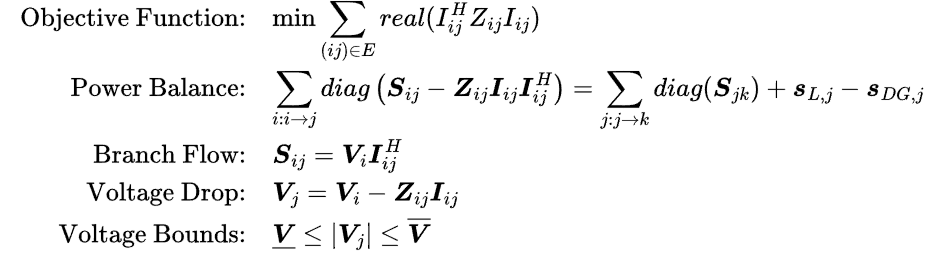![alt text](nlp.png)

## 10. Build and Solve Non linear  DOPF Model

In [13]:
import pyomo.environ as pyo
from math import atan2, degrees, sqrt
import matplotlib.pyplot as plt
import idaes
from amplpy.modules import find as ampl_find


solver = pyo.SolverFactory("ipopt")
print(solver.available())
print(solver.executable())

# Three-phase balanced initial voltage flat start
Unitphasor = np.array([1.0 + 0.0j, np.exp(-1j * 2 * np.pi / 3), np.exp(1j * 2 * np.pi / 3)])
Vinit = np.tile(Unitphasor, (tnode, 1))
Vr_init = np.real(Vinit)
Vi_init = np.imag(Vinit)
Vnom = 1.0

def build_opf_model(fix_spv=False):

    #Delclaring the variables and constraints for the NLP OPF model
    m = pyo.ConcreteModel("NLP_DOPF")
    m.BUSES = pyo.Set(initialize=all_buses)
    m.BRANCHES = pyo.RangeSet(1, brs)
    m.PHASES = pyo.RangeSet(1, 3)

    # Initialize voltage based on original bus ID and its mapped index
    def vr_init_rule(m, bus, phase):
        idx = bus_to_idx[bus]
        return Vr_init[idx, phase - 1]

    def vi_init_rule(m, bus, phase):
        idx = bus_to_idx[bus]
        return Vi_init[idx, phase - 1]

    m.Vr = pyo.Var(m.BUSES, m.PHASES, initialize=vr_init_rule)
    m.Vi = pyo.Var(m.BUSES, m.PHASES, initialize=vi_init_rule)
    m.Ir = pyo.Var(m.BRANCHES, m.PHASES, initialize=0.0)
    m.Ii = pyo.Var(m.BRANCHES, m.PHASES, initialize=0.0)
    m.Sbr_r = pyo.Var(m.BRANCHES, m.PHASES, initialize=0.0)
    m.Sbr_i = pyo.Var(m.BRANCHES, m.PHASES, initialize=0.0)
    m.SSlack_r = pyo.Var(m.PHASES, initialize=0.0)
    m.SSlack_i = pyo.Var(m.PHASES, initialize=0.0)
    m.SPv_var = pyo.Var(m.BUSES, m.PHASES, initialize=0.0)

    if fix_spv:
        for nid in all_buses:
            for p in range(1, 4):
                m.SPv_var[nid, p].fix(0.0)

    m.constraints = pyo.ConstraintList()

    # Slack bus constraints using original bus ID
    slack_idx = bus_to_idx[slack_bus]
    for p in range(1, 4):
        m.constraints.add(m.Vr[slack_bus, p] == Vr_init[slack_idx, p - 1])
        m.constraints.add(m.Vi[slack_bus, p] == Vi_init[slack_idx, p - 1])

    #Branch flow and power balance constraints for branch 'b' and phase 'p'
    for nid in sorted(all_buses):
        nid_0 = bus_to_idx[nid]
        inc = incbr[nid_0] #slack_bus has inc=0
        out_brs = [b for b in outbr[nid_0, :] if b != 0]

        if inc == 0: #sum of the downstream branch flows must equal the load at the slack bus
            for p in range(1, 4):
                m.constraints.add(m.SSlack_r[p] == sum(m.Sbr_r[ob, p] for ob in out_brs))
                m.constraints.add(m.SSlack_i[p] == sum(m.Sbr_i[ob, p] for ob in out_brs))

        elif len(out_brs) == 0: #the end bus; terminating bus with no downstream branches
            b = inc
            for p in range(1, 4): #Split the current equations into real and imaginary parts
                m.constraints.add(
                    m.Sbr_r[b, p]
                    - sum(Rval[p-1, k-1, b-1] * (m.Ir[b, k] * m.Ir[b, p] + m.Ii[b, k] * m.Ii[b, p])
                        + Xval[p-1, k-1, b-1] * (m.Ir[b, k] * m.Ii[b, p] - m.Ii[b, k] * m.Ir[b, p])
                          for k in range(1, 4))
                    == Pload[nid_0, p-1] - PPv[nid_0, p-1])
                m.constraints.add(
                    m.Sbr_i[b, p]
                    - sum(Rval[p-1, k-1, b-1] * (m.Ii[b, k] * m.Ir[b, p] - m.Ir[b, k] * m.Ii[b, p])
                        + Xval[p-1, k-1, b-1] * (m.Ir[b, k] * m.Ir[b, p] + m.Ii[b, k] * m.Ii[b, p])
                          for k in range(1, 4))
                    == Qload[nid_0, p-1] - m.SPv_var[nid, p])
        else:
            b = inc #The branch connecting this bus to its parent and downstream connections
            for p in range(1, 4):
                m.constraints.add(
                    m.Sbr_r[b, p]
                    - sum(Rval[p-1, k-1, b-1] * (m.Ir[b, k] * m.Ir[b, p] + m.Ii[b, k] * m.Ii[b, p])
                        + Xval[p-1, k-1, b-1] * (m.Ir[b, k] * m.Ii[b, p] - m.Ii[b, k] * m.Ir[b, p])
                          for k in range(1, 4))
                    == sum(m.Sbr_r[ob, p] for ob in out_brs)
                       + Pload[nid_0, p-1] - PPv[nid_0, p-1])
                m.constraints.add(
                    m.Sbr_i[b, p]
                    - sum(Rval[p-1, k-1, b-1] * (m.Ii[b, k] * m.Ir[b, p] - m.Ir[b, k] * m.Ii[b, p])
                        + Xval[p-1, k-1, b-1] * (m.Ir[b, k] * m.Ir[b, p] + m.Ii[b, k] * m.Ii[b, p])
                          for k in range(1, 4))
                    == sum(m.Sbr_i[ob, p] for ob in out_brs)
                       + Qload[nid_0, p-1] - m.SPv_var[nid, p])

        #DG inverter capability and voltage magnitude limits at bus 'nid' and phase 'p'
        for p in range(1, 4):
            m.constraints.add(-Qinv[nid_0, p-1] <= m.SPv_var[nid, p])
            m.constraints.add(m.SPv_var[nid, p] <= Qinv[nid_0, p-1])

        #Voltage constraints at bus 'nid' and phase 'p'
        for p in range(1, 4):
            m.constraints.add(m.Vr[nid, p]**2 + m.Vi[nid, p]**2 >= Vmin_pu**2)
            m.constraints.add(m.Vr[nid, p]**2 + m.Vi[nid, p]**2 <= Vmax_pu**2)

    for brid in range(1, brs + 1):
        brid_0 = brid - 1
        n1 = node1[brid_0]
        n2 = node2[brid_0]
        for p in range(1, 4):
            m.constraints.add(
                m.Vr[n2, p] == m.Vr[n1, p]
                - sum(Rval[p-1, k-1, brid_0] * m.Ir[brid, k]
                    - Xval[p-1, k-1, brid_0] * m.Ii[brid, k] for k in range(1, 4)))
            m.constraints.add(
                m.Vi[n2, p] == m.Vi[n1, p]
                - sum(Rval[p-1, k-1, brid_0] * m.Ii[brid, k]
                    + Xval[p-1, k-1, brid_0] * m.Ir[brid, k] for k in range(1, 4)))
            m.constraints.add(
                m.Sbr_r[brid, p] == m.Vr[n1, p] * m.Ir[brid, p] + m.Vi[n1, p] * m.Ii[brid, p])
            m.constraints.add(
                m.Sbr_i[brid, p] == m.Vi[n1, p] * m.Ir[brid, p] - m.Vr[n1, p] * m.Ii[brid, p])

    #Objective function: Minimize total real power losses in the network
    m.obj = pyo.Objective(
        expr=sum(
            sum(Rval[p-1, k-1, brid-1] * (m.Ir[brid, p] * m.Ir[brid, k] + m.Ii[brid, p] * m.Ii[brid, k])
              + Xval[p-1, k-1, brid-1] * (m.Ir[brid, p] * m.Ii[brid, k] - m.Ii[brid, p] * m.Ir[brid, k])
                for p in range(1, 4) for k in range(1, 4))
            for brid in range(1, brs + 1)),
        sense=pyo.minimize)
    return m


# Solve OPF with DG control
print("\nSolving nonlinear OPF (with DG control)...")
model = build_opf_model(fix_spv=False)
# ipopt_path = ampl_find('ipopt')
solver = pyo.SolverFactory("ipopt", executable="/root/.idaes/bin/ipopt")
solver.options["max_iter"] = 10000
solver.options["tol"] = 1e-6
solver.options["print_level"] = 5
results = solver.solve(model, tee=True)

# Results extraction
obj_val = pyo.value(model.obj)
Vval_control = np.full((tnode, 3), np.nan)
for bus in all_buses:
    idx = bus_to_idx[bus]
    for p in phase_avail[bus]:
        Vval_control[idx, p-1] = sqrt(pyo.value(model.Vr[bus, p])**2 + pyo.value(model.Vi[bus, p])**2)
Loss_control = obj_val * baseMVA / 1000
print(f"=== OPF Loss (with DG control): {Loss_control:.4f} kW ===")

# Solve base case (no DG reactive power control)
print("\nSolving base case (no DG reactive power control)...")
model_base = build_opf_model(fix_spv=True)
results_base = solver.solve(model_base, tee=True)
Vval_nocontrol = np.full((tnode, 3), np.nan)
for bus in all_buses:
    idx = bus_to_idx[bus]
    for p in phase_avail[bus]:
        Vval_nocontrol[idx, p-1] = sqrt(pyo.value(model_base.Vr[bus, p])**2 + pyo.value(model_base.Vi[bus, p])**2)
Loss_nocontrol = pyo.value(model_base.obj) * baseMVA / 1000
print(f"=== Base Case Loss (no DG control): {Loss_nocontrol:.4f} kW ===")

True
/root/.idaes/bin/ipopt

Solving nonlinear OPF (with DG control)...
Ipopt 3.13.2: max_iter=10000
tol=1e-06
print_level=5


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowle

In [14]:
# Save the "with DG control" voltages to Excel

output_dir = os.getcwd()
os.makedirs(output_dir, exist_ok=True)
excel_out_ctrl = os.path.join(output_dir, "Voltage with DG Control (NLP DOPF).xlsx")
wb_out_ctrl = openpyxl.Workbook()
ws_out_ctrl = wb_out_ctrl.active
ws_out_ctrl.title = "With_DG_Control"

ws_out_ctrl.append(["Node", "Phase A", "Phase B", "Phase C"])
for bus in all_buses:
    idx = bus_to_idx[bus]
    row_vals = [bus]
    for ph in range(3):
        v = Vval_control[idx, ph]
        row_vals.append(None if np.isnan(v) else float(round(v, 6)))
    ws_out_ctrl.append(row_vals)

wb_out_ctrl.save(excel_out_ctrl)
print(f"Saved Excel file: {excel_out_ctrl}")

Saved Excel file: /content/Voltage with DG Control (NLP DOPF).xlsx


In [15]:

print("\n─── Voltage Magnitudes (without DG control) ────────────")
print(f"{'Node':>6s}  {'Phase A':>10s}  {'Phase B':>10s}  {'Phase C':>10s}")
for bus in all_buses:
    idx = bus_to_idx[bus]
    vals = []
    for ph in range(3):
        v = round(Vval_nocontrol[idx, ph], 3)
        vals.append("   ---   " if np.isnan(v) else f"  {v:.3f}")
    print(f"{str(bus):>6s}  {vals[0]:>10s}  {vals[1]:>10s}  {vals[2]:>10s}")

# Save the "without DG control" voltages to Excel
output_dir = os.getcwd()
os.makedirs(output_dir, exist_ok=True)
excel_out_no_ctrl = os.path.join(output_dir, "Voltage without DG Control (NLP DOPF).xlsx")
wb_out_no_ctrl = openpyxl.Workbook()
ws_out_no_ctrl = wb_out_no_ctrl.active
ws_out_no_ctrl.title = "Without_DG_Control"

ws_out_no_ctrl.append(["Node", "Phase A", "Phase B", "Phase C"])
for bus in all_buses:
    idx = all_buses.index(bus)
    row_vals = [bus]
    for ph in range(3):
        v = Vval_nocontrol[idx, ph]
        row_vals.append(None if np.isnan(v) else float(round(v, 6)))
    ws_out_no_ctrl.append(row_vals)

wb_out_no_ctrl.save(excel_out_no_ctrl)
print(f"Saved Excel file: {excel_out_no_ctrl}")




─── Voltage Magnitudes (without DG control) ────────────
  Node     Phase A     Phase B     Phase C
     1       0.995       1.000       1.005
     2      ---          1.000      ---   
     3      ---         ---          1.012
     4      ---         ---          1.012
     5      ---         ---          1.018
     6      ---         ---          1.022
     7       0.995       0.997       1.006
     8       0.996       0.996       1.007
     9       1.001      ---         ---   
    10       1.012      ---         ---   
    11       1.019      ---         ---   
    12      ---          0.995      ---   
    13       0.995       0.996       1.006
    14       1.012      ---         ---   
    15      ---         ---          1.009
    16      ---         ---          1.013
    17      ---         ---          1.008
    18       0.992       0.995       1.013
    19       0.991      ---         ---   
    20       0.990      ---         ---   
    21       0.993       0.995       1.

## 11. Plot Results

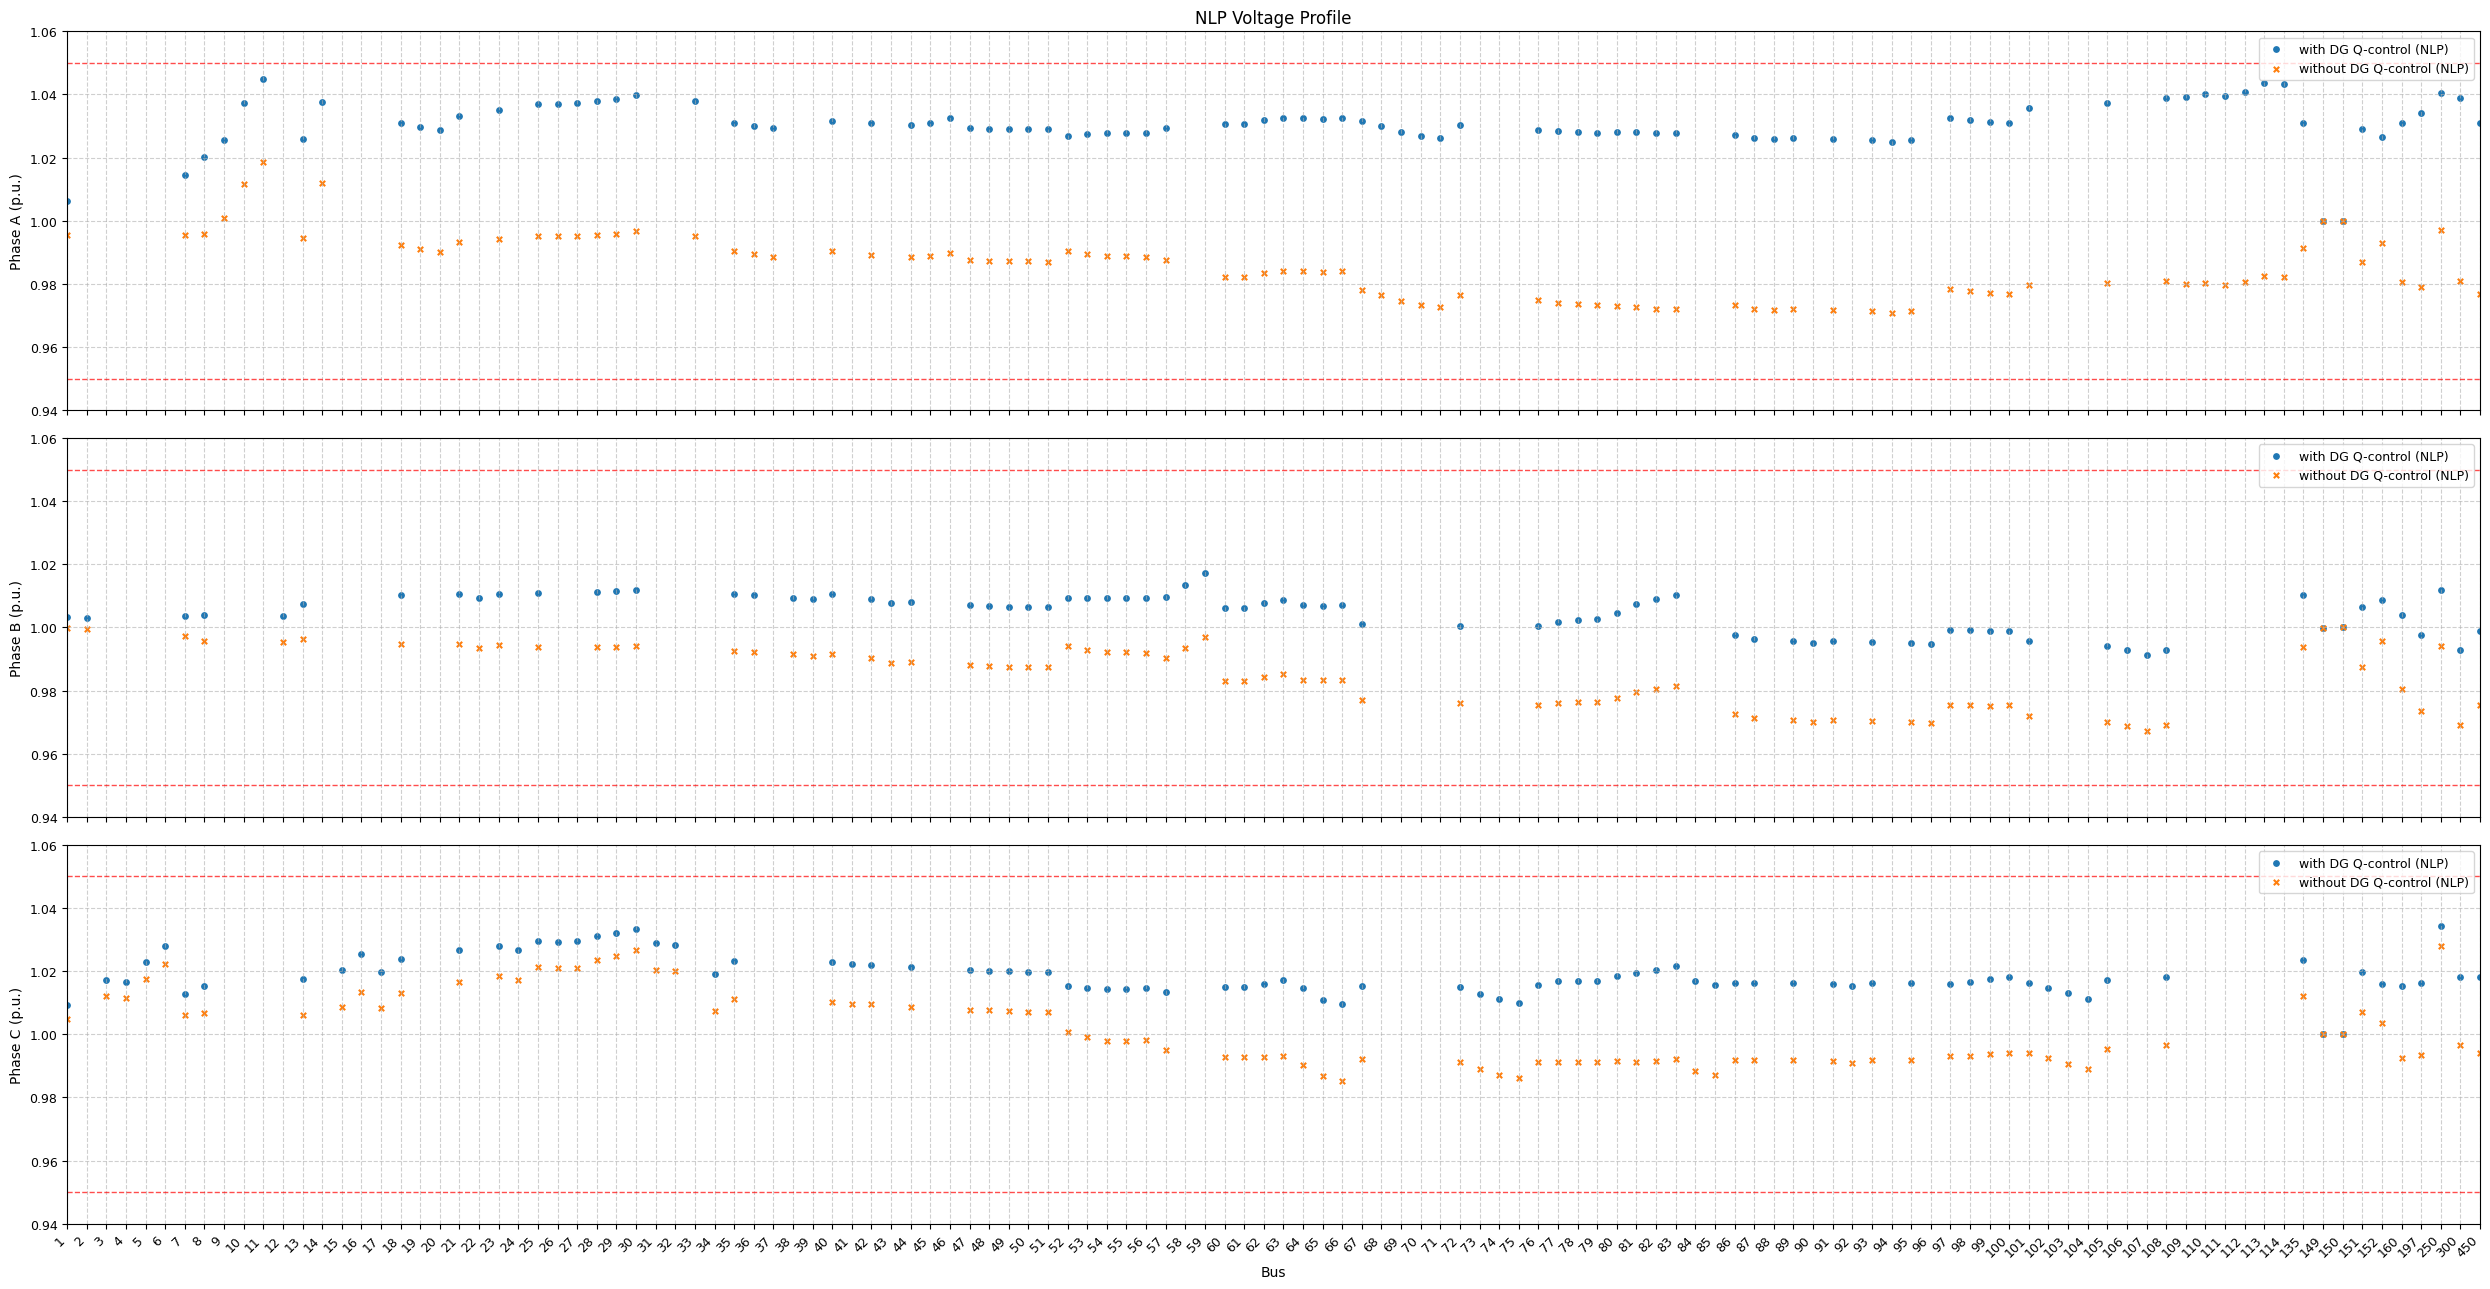

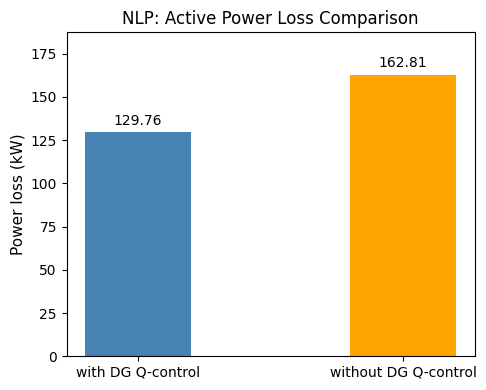

In [16]:
x_labels = list(all_buses)
x_pos = np.arange(len(x_labels))
fig, axes = plt.subplots(3, 1, figsize=(25, 13), sharex=True)
phase_labels = ["Phase A", "Phase B", "Phase C"]

for idx, ax in enumerate(axes):
    ax.scatter(x_pos, Vval_control[:, idx], marker='o', s=15, label="with DG Q-control (NLP)")
    ax.scatter(x_pos, Vval_nocontrol[:, idx], marker='x', s=15, label="without DG Q-control (NLP)")

    ax.set_ylabel(f"{phase_labels[idx]} (p.u.)")
    ax.set_xlim(0, len(x_labels) - 1)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.legend(loc="upper right", fontsize=9)
    ax.tick_params(labelsize=9)
    ax.set_ylim(0.94, 1.06)
    ax.horizontal_line = ax.axhline(0.95, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.horizontal_line = ax.axhline(1.05, color='red', linestyle='--', linewidth=1, alpha=0.7)

    ax.grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel("Bus")
axes[0].set_title("NLP Voltage Profile")
plt.tight_layout()
plt.savefig(r'NLP_voltage_profile.png', dpi=300)
plt.show()


fig2, ax2 = plt.subplots(figsize=(5, 4))
loss_kW = [Loss_control, Loss_nocontrol]

bars = ax2.bar(["with DG Q-control", "without DG Q-control"], loss_kW,
               width=0.4, color=["steelblue", "orange"])
ax2.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
ax2.set_ylabel("Power loss (kW)", fontsize=11)
ax2.set_title("NLP: Active Power Loss Comparison")
ax2.set_ylim(0, max(loss_kW) * 1.15)
ax2.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig( r"nlp_loss_comparison.png", dpi=300)
plt.show()